In [2]:
import pandas as pd

In [3]:
df_confirmed = pd.read_excel("covid_19_dataset-1718175635.xlsx", sheet_name ="covid_19_confirmed_v1")
df_deaths = pd.read_csv("covid_19_deaths_v1.csv", header = 1)
df__recovered = pd.read_csv("covid_19_recovered_v1.csv", header = 1)        # header = 1 means first row is header, not 0

In [4]:
df_confirmed.head(3)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456


In [5]:
df_deaths.head(3)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,3401,3405,3411,3418,3426,3433,3440,3448,3455,3460


In [6]:
df__recovered.head(3)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419


In [7]:
# for some countries we have data for there stated as well as for their provinces, so we need to group by country and sum the values of all the provinces to get the total number of cases for that country
df_confirmed.loc[df_confirmed['Country/Region'] == "China"]         # checking for china, 

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
58,Anhui,China,31.8257,117.2264,1,9,15,39,60,70,...,1001,1001,1002,1002,1004,1004,1004,1004,1004,1004
59,Beijing,China,40.1824,116.4142,14,22,36,41,68,80,...,1057,1057,1058,1058,1058,1058,1059,1059,1059,1059
60,Chongqing,China,30.0572,107.8740,6,9,27,57,75,110,...,598,598,598,598,598,598,598,598,598,598
61,Fujian,China,26.0789,117.9874,1,5,10,18,35,59,...,610,610,612,613,615,616,617,617,618,620
62,Gansu,China,35.7518,104.2861,0,2,2,4,7,14,...,193,193,193,194,194,194,194,194,194,194
63,Guangdong,China,23.3417,113.4244,26,32,53,78,111,151,...,2400,2406,2409,2412,2412,2413,2427,2428,2431,2432
64,Guangxi,China,23.8298,108.7881,2,5,23,23,36,46,...,275,275,275,275,275,275,275,275,275,275
65,Guizhou,China,26.8154,106.8748,1,3,3,4,5,7,...,147,147,147,147,147,147,147,147,147,147
66,Hainan,China,19.1959,109.7453,4,5,8,19,22,33,...,188,188,188,188,188,188,188,188,188,188
67,Hebei,China,39.5490,116.1306,1,1,2,8,13,18,...,1317,1317,1317,1317,1317,1317,1317,1317,1317,1317


In [8]:
df_confirmed_new = df_confirmed.drop(['Province/State', 'Lat', 'Long'], axis = 1)     
# dropping the columns which we don't want to sum

df_confirmed_country = df_confirmed_new.groupby('Country/Region').sum()            
# group by country and sum the values pf all the provinces, this will give us the total number of cases for each country, but it will also sum the lat and long values which we don't want, so we will drop those columns

In [12]:
df_confirmed_country.head()                 # if we want to make the country column as index or make  it as a column the we can use set_index() or reset_index() respectively

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
Albania,0,0,0,0,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297
Algeria,0,0,0,0,0,0,0,0,0,0,...,126156,126434,126651,126860,127107,127361,127646,127926,128198,128456
Andorra,0,0,0,0,0,0,0,0,0,0,...,13569,13569,13569,13569,13569,13664,13671,13682,13693,13693
Angola,0,0,0,0,0,0,0,0,0,0,...,31661,31909,32149,32441,32623,32933,33338,33607,33944,34180


In [16]:
# this will sort the by 5/29/21 which is last column in dataset, in descending order, so that we can see the countries with the highest number of cases at the top
df_confirmed_country.sort_values(by ='5/29/21', ascending=False, inplace=True)


In [17]:
df_confirmed_country.head()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
US,1,1,2,2,5,5,5,6,6,8,...,33056765,33085106,33104884,33117737,33143662,33166418,33190470,33217995,33239963,33251939
India,0,0,0,0,0,0,0,0,1,1,...,26031991,26289290,26530132,26752447,26948874,27157795,27369093,27555457,27729247,27894800
Brazil,0,0,0,0,0,0,0,0,0,0,...,15894094,15970949,16047439,16083258,16120756,16194209,16274695,16342162,16391930,16471600
France,0,0,2,3,3,3,4,5,5,5,...,5629983,5642786,5655397,5665101,5667331,5670486,5683143,5697076,5708350,5719877
Turkey,0,0,0,0,0,0,0,0,0,0,...,5160423,5169951,5178648,5186487,5194010,5203385,5212123,5220549,5228322,5235978


In [ ]:
df_confirmed_country.iloc[:10, -1]        # this will give us the number of cases for the top 10 countries on 5/29/21(last column i.e., -1 position)   

Country/Region
US                33251939
India             27894800
Brazil            16471600
France             5719877
Turkey             5235978
Russia             4995613
United Kingdom     4496823
Italy              4213055
Argentina          3732263
Germany            3684672
Name: 5/29/21, dtype: int64

In [20]:
import matplotlib.pyplot as plt

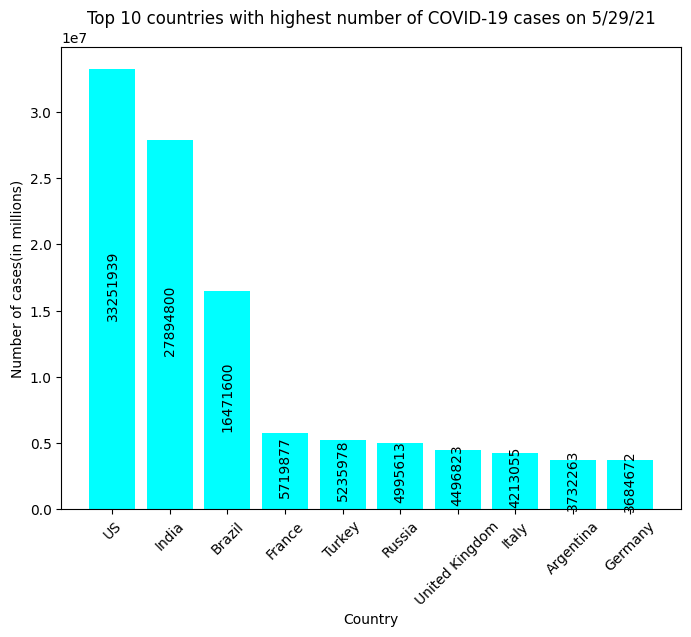

In [35]:
plt.figure(figsize=(8,6))
t=plt.bar(df_confirmed_country.index[:10], df_confirmed_country.iloc[:10, -1], color='cyan')

plt.bar_label(t, fmt= '%.0f', padding=3,label_type= 'center', rotation=90)        # this will add the labels on top of the bars, fmt is used to format the labels, %.0f means we want to show the labels as integers, padding is used to add some space between the labels and the bars
plt.title("Top 10 countries with highest number of COVID-19 cases on 5/29/21")
plt.xlabel("Country")
plt.ylabel("Number of cases(in millions)")
plt.xticks(rotation=45)
plt.show()

In [37]:
df_confirmed_china = df_confirmed.loc[df_confirmed['Country/Region'] =='China', :]

In [42]:
df_confirmed_china.shape        # we have 34 rows for china, which means we have data for 34 provinces of china

(34, 498)

In [43]:
df_confirmed_china.sort_values(by = '5/29/21', ascending =False, inplace =True)

C:\Users\sachi\AppData\Local\Temp\ipykernel_18208\2023626867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_confirmed_china.sort_values(by = '5/29/21', ascending =False, inplace =True)


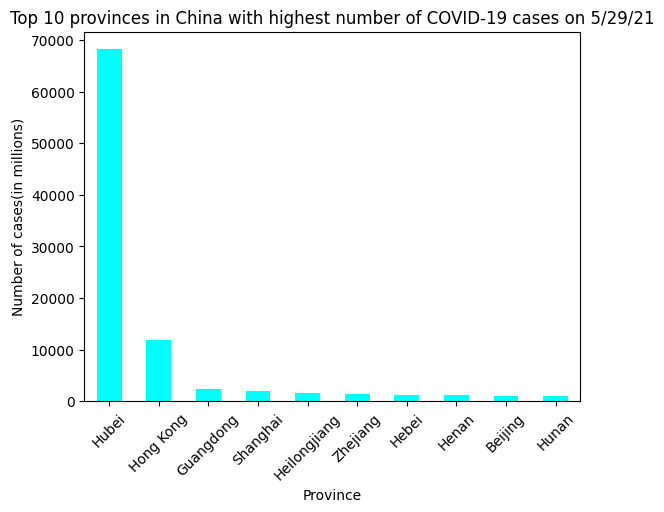

In [46]:
df_confirmed_china.set_index('Province/State').iloc[:10, -1].plot(kind='bar', color='cyan')
plt.title("Top 10 provinces in China with highest number of COVID-19 cases on 5/29/21")
plt.xlabel("Province")
plt.ylabel("Number of cases(in millions)")
plt.xticks(rotation=45)
plt.show()